In [12]:
# ---------------------------------------------------------------
# STEP 1: Import Required Libraries
# ---------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import requests

In [16]:
# ---------------------------------------------------------------
# STEP 2: Access Data from CSV File (Local Repository)
# ---------------------------------------------------------------

# Load dataset
df = pd.read_csv("student.csv")

print("----- CSV Repository Access -----")

# Display first 5 rows
print(_df.head())

----- CSV Repository Access -----
   student_id first_name   last_name  age                        email  \
0           1    Kerrill   De Cleyne   24          kdecleyne0@furl.net   
1           2    Krissie      Vittet   25          kvittet1@ustream.tv   
2           3   Hugibert       Haugg   21      hhaugg2@theguardian.com   
3           4     Fancie     De Mars   18       fdemars3@parallels.com   
4           5      Micki  O'Dowgaine   24  modowgaine4@livejournal.com   

       country  grade_math  grade_science  grade_english  total_score  
0    Venezuela          68             80             15           54  
1     Bulgaria          29             30             60           39  
2  New Zealand          76              0             55           43  
3        China          82             88             90           86  
4        China          77             23             11           37  


In [33]:
# STEP 2*: Convert CSV to JSON

df.to_json("student.json", orient="records", indent=4)

print("JSON file created successfully")

JSON file created successfully


In [34]:
# ---------------------------------------------------------------
# STEP 3: Identify Source Information of Dataset
# ---------------------------------------------------------------

print("\n----- Repository Identification -----")

print("Data Source: Local CSV File Repository")

# Shape of dataset
print("Dataset Shape:", _df.shape)

# Column names
print("\nDataset Columns:")
print(_df.columns)

# Dataset information
print("\nDataset Info:")
_df.info()


----- Repository Identification -----
Data Source: Local CSV File Repository
Dataset Shape: (1000, 10)

Dataset Columns:
Index(['student_id', 'first_name', 'last_name', 'age', 'email', 'country',
       'grade_math', 'grade_science', 'grade_english', 'total_score'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   student_id     1000 non-null   int64 
 1   first_name     1000 non-null   object
 2   last_name      1000 non-null   object
 3   age            1000 non-null   int64 
 4   email          1000 non-null   object
 5   country        1000 non-null   object
 6   grade_math     1000 non-null   int64 
 7   grade_science  1000 non-null   int64 
 8   grade_english  1000 non-null   int64 
 9   total_score    1000 non-null   int64 
dtypes: int64(6), object(4)
memory usage: 78.3+ KB


In [35]:
# ---------------------------------------------------------------
# STEP 4: Identify Data Format and Structure
# ---------------------------------------------------------------

print("\n----- Data Format and Structure -----")

# Check datatype of each column
print(_df.dtypes)

print("\nData Structure: Structured Data (rows and columns)")


----- Data Format and Structure -----
student_id        int64
first_name       object
last_name        object
age               int64
email            object
country          object
grade_math        int64
grade_science     int64
grade_english     int64
total_score       int64
dtype: object

Data Structure: Structured Data (rows and columns)


In [36]:
# ---------------------------------------------------------------
# STEP 5: Statistical Summary
# ---------------------------------------------------------------

print("\n----- Statistical Summary -----")

print(_df.describe())


----- Statistical Summary -----
        student_id          age   grade_math  grade_science  grade_english  \
count  1000.000000  1000.000000  1000.000000    1000.000000    1000.000000   
mean    500.500000    21.536000    50.057000      48.335000      50.634000   
std     288.819436     2.275936    28.868723      29.229114      29.896619   
min       1.000000    18.000000     0.000000       0.000000       0.000000   
25%     250.750000    20.000000    24.000000      24.000000      24.000000   
50%     500.500000    21.000000    51.000000      47.000000      50.000000   
75%     750.250000    23.000000    74.000000      74.000000      77.250000   
max    1000.000000    25.000000   100.000000     100.000000     100.000000   

       total_score  
count  1000.000000  
mean     49.341000  
std      16.801399  
min       7.000000  
25%      37.000000  
50%      49.500000  
75%      62.000000  
max      92.000000  


In [37]:
# ---------------------------------------------------------------
# STEP 6: Missing Value Analysis
# ---------------------------------------------------------------

print("\n----- Missing Values -----")

print(_df.isnull().sum())


----- Missing Values -----
student_id       0
first_name       0
last_name        0
age              0
email            0
country          0
grade_math       0
grade_science    0
grade_english    0
total_score      0
dtype: int64


In [38]:
# ---------------------------------------------------------------
# STEP 7: Duplicate Record Check
# ---------------------------------------------------------------

print("\n----- Duplicate Records -----")

print("Duplicate Rows:", _df.duplicated().sum())


----- Duplicate Records -----
Duplicate Rows: 0


In [39]:
# ---------------------------------------------------------------
# STEP 8: Exploratory Data Analysis
# ---------------------------------------------------------------

print("\n----- Result Distribution -----")

print(_df['total_score'].value_counts())


----- Result Distribution -----
total_score
43    30
56    28
55    27
52    25
44    24
      ..
91     1
87     1
17     1
89     1
7      1
Name: count, Length: 85, dtype: int64


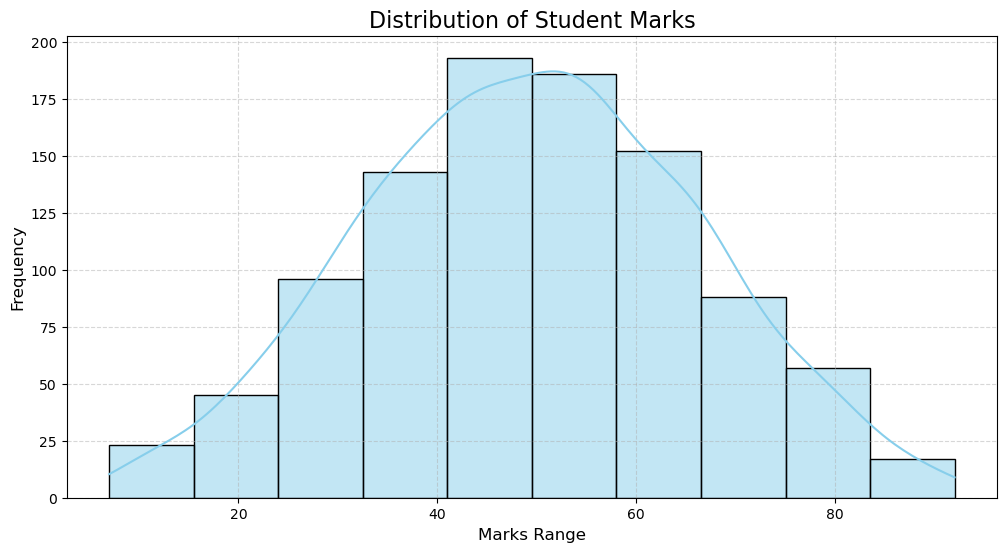

In [40]:
# ---------------------------------------------------------------
# STEP 9: Visualization
# ---------------------------------------------------------------

plt.figure(figsize=(12,6))

sns.histplot(df['total_score'], bins=10, color='skyblue', edgecolor='black', kde=True)

plt.xticks(rotation=0)

plt.title('Distribution of Student Marks', fontsize=16)
plt.xlabel('Marks Range', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

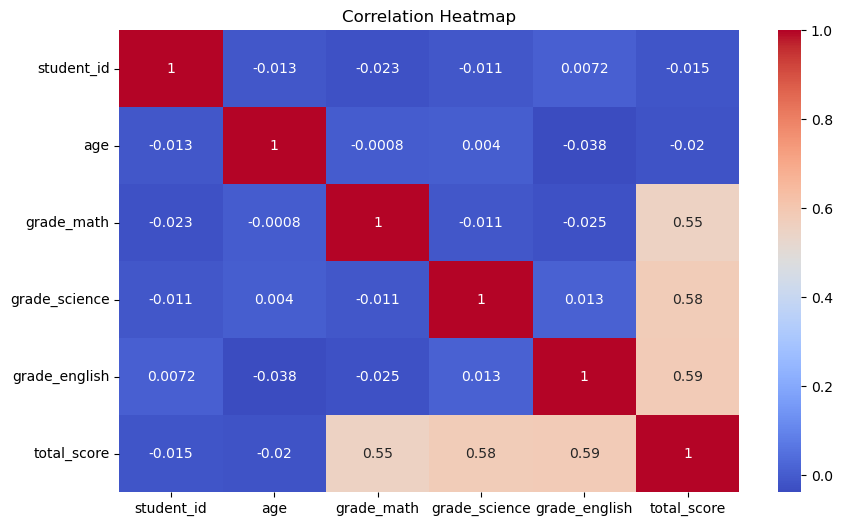

In [41]:
# ---------------------------------------------------------------
# STEP 10: Correlation Analysis
# ---------------------------------------------------------------

numeric_df = _df.select_dtypes(include=['int64', 'float64'])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10,6))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

In [42]:
# ---------------------------------------------------------------
# STEP 11: SQLite Repository Demonstration
# ---------------------------------------------------------------

# Create SQLite database
connection = sqlite3.connect('student_database.db')

# Store dataset in SQL table
_df.to_sql('student_table', connection, if_exists='replace', index=False)

# Read data back from database
sql_data = pd.read_sql('SELECT * FROM student_table LIMIT 5', connection)

print("\n----- SQLite Repository Access -----")

print(sql_data)

# Close connection
connection.close()


----- SQLite Repository Access -----
   student_id first_name   last_name  age                        email  \
0           1    Kerrill   De Cleyne   24          kdecleyne0@furl.net   
1           2    Krissie      Vittet   25          kvittet1@ustream.tv   
2           3   Hugibert       Haugg   21      hhaugg2@theguardian.com   
3           4     Fancie     De Mars   18       fdemars3@parallels.com   
4           5      Micki  O'Dowgaine   24  modowgaine4@livejournal.com   

       country  grade_math  grade_science  grade_english  total_score  
0    Venezuela          68             80             15           54  
1     Bulgaria          29             30             60           39  
2  New Zealand          76              0             55           43  
3        China          82             88             90           86  
4        China          77             23             11           37  


In [43]:
# ---------------------------------------------------------------
# STEP 12: API Repository Demonstration
# ---------------------------------------------------------------

url = 'https://jsonplaceholder.typicode.com/posts/1'

response = requests.get(url)

print("\n----- API Repository Access -----")

print(response.json())


----- API Repository Access -----
{'userId': 1, 'id': 1, 'title': 'sunt aut facere repellat provident occaecati excepturi optio reprehenderit', 'body': 'quia et suscipit\nsuscipit recusandae consequuntur expedita et cum\nreprehenderit molestiae ut ut quas totam\nnostrum rerum est autem sunt rem eveniet architecto'}


In [44]:
# ---------------------------------------------------------------
# STEP 13: Final Conclusion
# ---------------------------------------------------------------

print("\n----- Practical Conclusion -----")

print("1. Successfully accessed dataset from CSV repository")
print("2. Identified data structure and format")
print("3. Performed statistical analysis")
print("4. Checked missing values and duplicates")
print("5. Performed visualization and correlation analysis")
print("6. Demonstrated SQLite repository usage")
print("7. Demonstrated API repository access")


----- Practical Conclusion -----
1. Successfully accessed dataset from CSV repository
2. Identified data structure and format
3. Performed statistical analysis
4. Checked missing values and duplicates
5. Performed visualization and correlation analysis
6. Demonstrated SQLite repository usage
7. Demonstrated API repository access
